In [1]:

import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt 
from collections import Counter
from wordcloud import WordCloud
%matplotlib inline 

In [2]:
df=pd.read_csv("/kaggle/input/netflix-data-anylasis/netflix_titles.csv")

In [3]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...
...,...,...,...,...,...,...,...,...,...,...,...,...
6229,80000063,TV Show,Red vs. Blue,NaN,"Burnie Burns, Jason Saldaña, Gustavo Sorola, G...",United States,NaN,2015,NR,13 Seasons,"TV Action & Adventure, TV Comedies, TV Sci-Fi ...","This parody of first-person shooter games, mil..."
6230,70286564,TV Show,Maron,NaN,"Marc Maron, Judd Hirsch, Josh Brener, Nora Zeh...",United States,NaN,2016,TV-MA,4 Seasons,TV Comedies,"Marc Maron stars as Marc Maron, who interviews..."
6231,80116008,Movie,Little Baby Bum: Nursery Rhyme Friends,NaN,NaN,NaN,NaN,2016,NaN,60 min,Movies,Nursery rhymes and original music for children...
6232,70281022,TV Show,A Young Doctor's Notebook and Other Stories,NaN,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,NaN,2013,TV-MA,2 Seasons,"British TV Shows, TV Comedies, TV Dramas","Set during the Russian Revolution, this comic ..."


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6234 entries, 0 to 6233
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       6234 non-null   int64 
 1   type          6234 non-null   object
 2   title         6234 non-null   object
 3   director      4265 non-null   object
 4   cast          5664 non-null   object
 5   country       5758 non-null   object
 6   date_added    6223 non-null   object
 7   release_year  6234 non-null   int64 
 8   rating        6224 non-null   object
 9   duration      6234 non-null   object
 10  listed_in     6234 non-null   object
 11  description   6234 non-null   object
dtypes: int64(2), object(10)
memory usage: 584.6+ KB


In [5]:
df.describe()

,show_id,release_year
count,6.234000e+03,6234.00000
mean,7.670368e+07,2013.35932
std,1.094296e+07,8.81162
min,2.477470e+05,1925.00000
25%,8.003580e+07,2013.00000
50%,8.016337e+07,2016.00000
75%,8.024489e+07,2018.00000
max,8.123573e+07,2020.00000


In [6]:
df.isnull().sum()

show_id            0
type               0
title              0
director        1969
cast             570
country          476
date_added        11
release_year       0
rating            10
duration           0
listed_in          0
description        0
dtype: int64

In [7]:
df['date_added'] = df['date_added'].str.strip()  # remove spaces like " September"
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [8]:

df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [9]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China",2019-09-09,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...,2019.0,9.0
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,2016-09-09,2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...,2016.0,9.0
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,2018-09-08,2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob...",2018.0,9.0
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,2018-09-08,2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...,2018.0,9.0
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,2017-09-08,2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...,2017.0,9.0


In [10]:
# Fill missing values
for col in ['country', 'director', 'cast', 'rating', 'duration']:
    df[col].fillna('unknown')

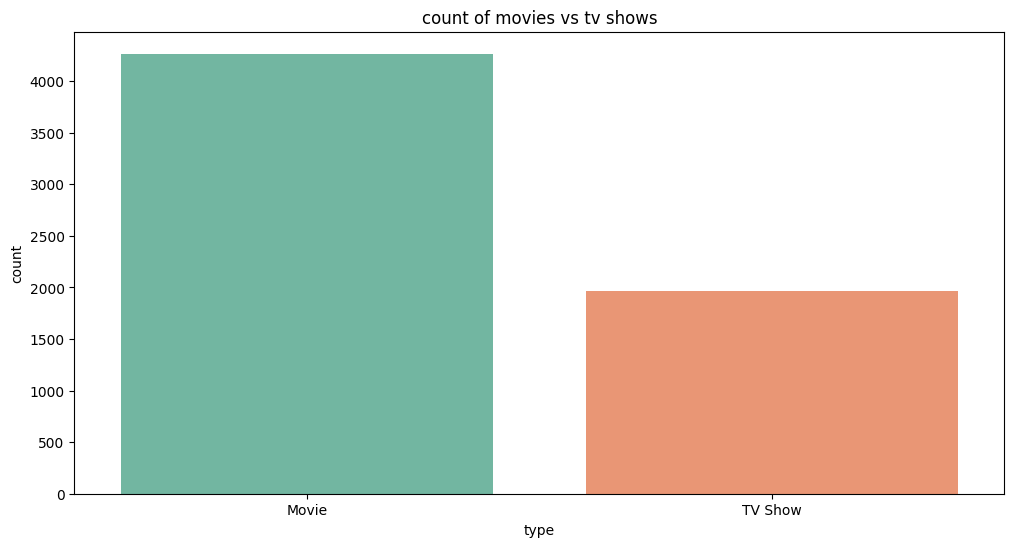

In [11]:
plt.figure(figsize = (12,6))
sns.countplot(data = df , x = 'type' ,palette = 'Set2')
plt.title('count of movies vs tv shows')
plt.show()

In [12]:
top_country = df['country'].value_counts().head()
top_country

country
United States     2032
India              777
United Kingdom     348
Japan              176
Canada             141
Name: count, dtype: int64

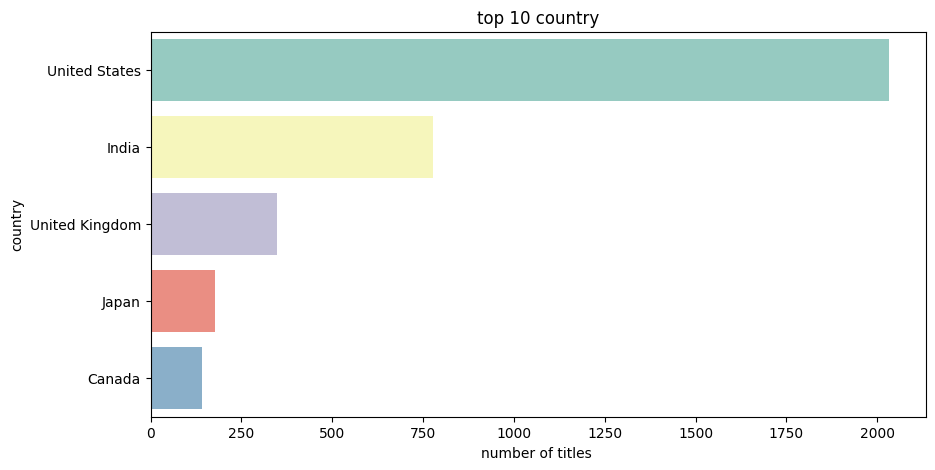

In [13]:
plt.figure(figsize = (10 ,5))
sns.barplot(x = top_country.values, y = top_country.index , palette = 'Set3')
plt.title('top 10 country')
plt.xlabel('number of titles ')
plt.ylabel("country")
plt.show()

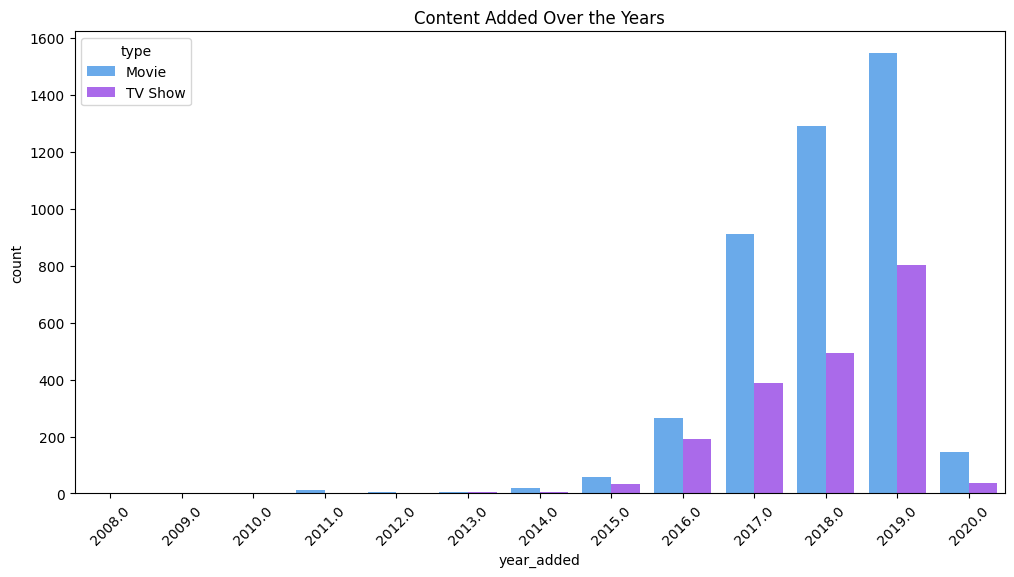

In [14]:
# ✅ Step 7: Content Added by Year
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='year_added', hue='type', palette='cool')
plt.title('Content Added Over the Years')
plt.xticks(rotation=45)
plt.show()

In [15]:
# ✅ Step 8: Monthly Trend of Releases
monthly_release = df['month_added'].value_counts().sort_index()
monthly_release

month_added
1.0     610
2.0     378
3.0     551
4.0     447
5.0     428
6.0     393
7.0     474
8.0     509
9.0     479
10.0    646
11.0    612
12.0    696
Name: count, dtype: int64

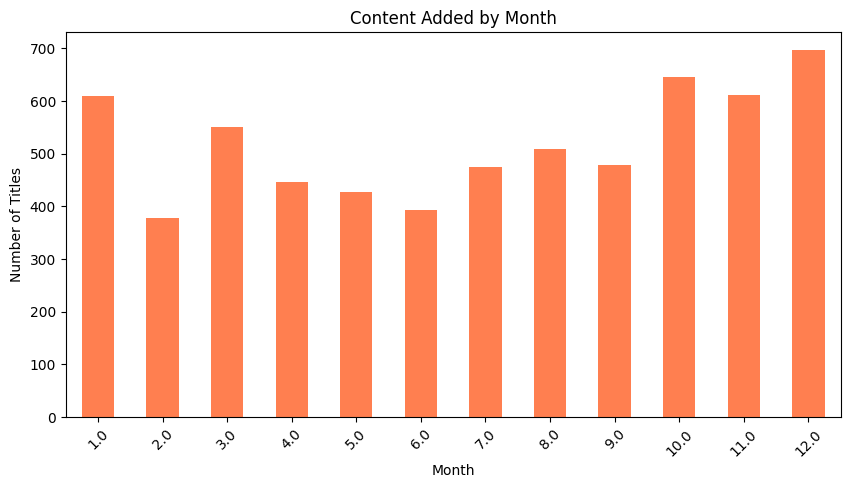

In [16]:
plt.figure(figsize=(10, 5))
monthly_release.plot(kind='bar', color='coral')
plt.title('Content Added by Month')
plt.xlabel('Month')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

In [17]:
# ✅ Step 9: Top 10 Genres
all_genres = df['listed_in'].dropna().apply(lambda x: x.split(', '))
genre_count = Counter([g for sublist in all_genres for g in sublist])
top_genres = genre_count.most_common(10)
genres_df = pd.DataFrame(top_genres, columns=['Genre', 'Count'])
genres_df

,Genre,Count
0,International Movies,1927
1,Dramas,1623
2,Comedies,1113
3,International TV Shows,1001
4,Documentaries,668
5,TV Dramas,599
6,Action & Adventure,597
7,Independent Movies,552
8,TV Comedies,436
9,Thrillers,392


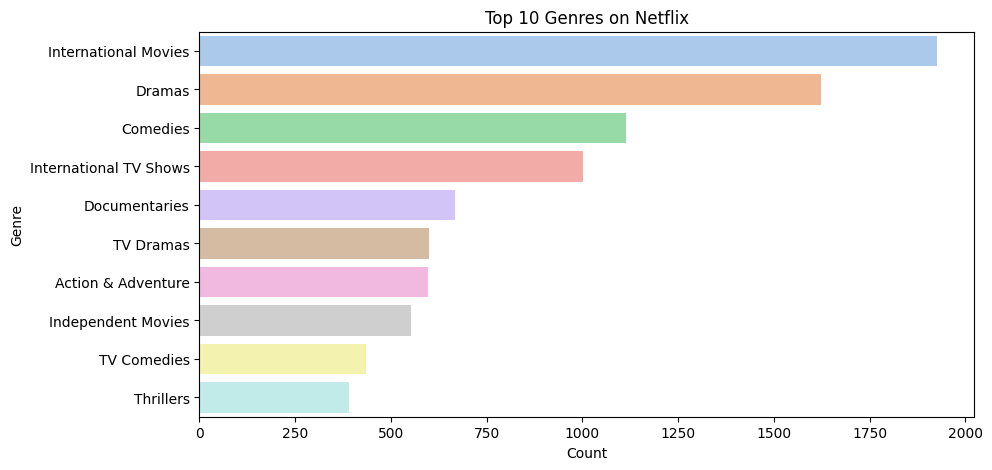

In [18]:
plt.figure(figsize=(10, 5))
sns.barplot(data=genres_df, y='Genre', x='Count', palette='pastel')
plt.title('Top 10 Genres on Netflix')
plt.show()

In [19]:
top_directors = df[df['director'] != 'Unknown']['director'].value_counts().head(10)
top_directors

director
Raúl Campos, Jan Suter    18
Marcus Raboy              14
Jay Karas                 13
Jay Chapman               12
Steven Spielberg           9
Martin Scorsese            9
Lance Bangs                8
David Dhawan               8
Johnnie To                 8
Shannon Hartman            7
Name: count, dtype: int64

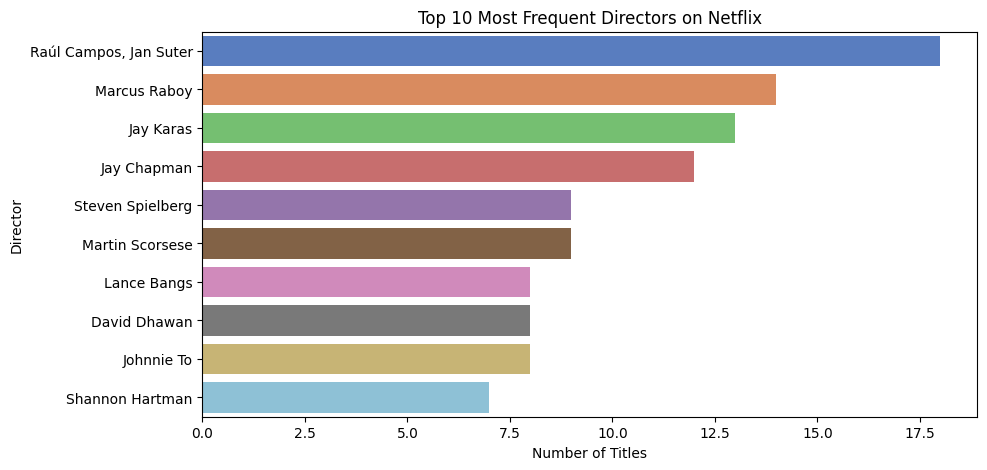

In [20]:
plt.figure(figsize=(10, 5))
sns.barplot(x=top_directors.values, y=top_directors.index, palette='muted')
plt.title('Top 10 Most Frequent Directors on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Director')
plt.show()

In [21]:
movies_df = df[df['type'] == 'Movie'].copy()
movies_df['duration_int'] = movies_df['duration'].str.extract(r'(\d+)').astype(float)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


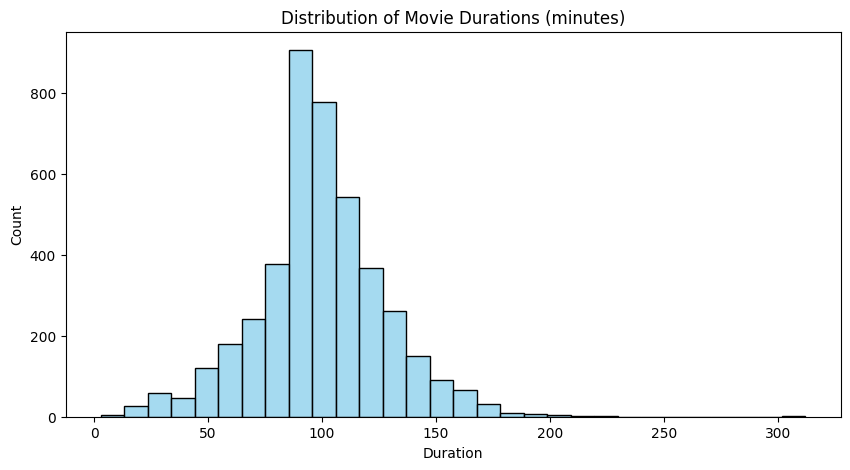

In [22]:
plt.figure(figsize=(10, 5))
sns.histplot(data=movies_df, x='duration_int', bins=30, color='skyblue')
plt.title('Distribution of Movie Durations (minutes)')
plt.xlabel('Duration')
plt.show()

In [23]:
# ✅ Step 12: Word Cloud for Descriptions
text = ' '.join(df['description'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='black', colormap='Set2', max_words=100).generate(text)


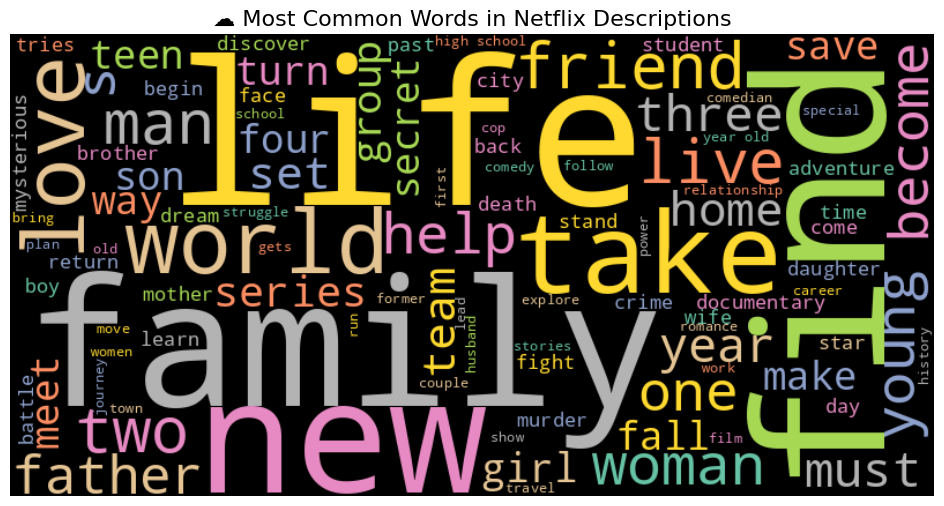

In [24]:
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('☁️ Most Common Words in Netflix Descriptions', fontsize=16)
plt.show()

In [25]:
# ✅ Step 14: TV Show Seasons Analysis
tv_df = df[df['type'] == 'TV Show'].copy()
tv_df['seasons'] = tv_df['duration'].str.extract(r'(\d+)').astype(float)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


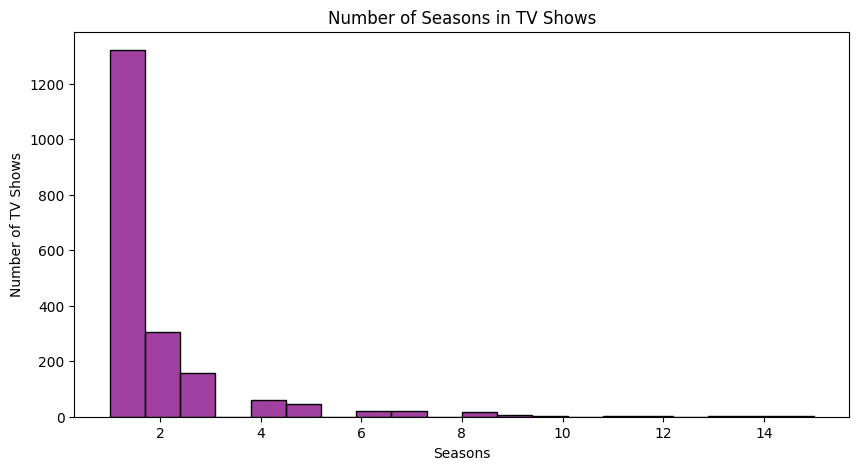

In [26]:
plt.figure(figsize=(10, 5))
sns.histplot(tv_df['seasons'], bins=20, color='purple')
plt.title('Number of Seasons in TV Shows')
plt.xlabel('Seasons')
plt.ylabel('Number of TV Shows')
plt.show()
